# EXPLORATORY DATA ANALYSIS

lets understand the dataset and make it ready for modeling and feature engineering by cleaning and optimizing the data.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
data = pd.read_csv('/home/spandan/Documents/sumago/Traffic-Prediction/dataset/dataset.csv')
test = pd.read_csv('/home/spandan/Documents/sumago/Traffic-Prediction/dataset/dataset.csv')


In [32]:
data.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [33]:
data.columns


Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='str')

alr so lets ourself introduced to the dataset first. well the dataset is quite huge as of the preview , with 9 columns.

In [34]:
data.shape

(48204, 9)

In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 3.3 MB


the data has ~48000 rows

from the description of the dataset provided , lets break down each column's information.

---
> features (x)

1. holiday -> all the US national holidays. [categorical]  
2. temp -> temperature , average temperature the whole day in kelvin. [continous]  
3. rain_1h -> amount of rainfall in mm , that occured in an hour. [continous]  
4. snow_1h -> amount of snowfall occured in the rain that particular hour. [continous]  
5. clouds_all -> cloud cover's percentage [integer]  
6. weather_main -> textual description of current weather [categorical]  
7. weather_description -> long textual description of weather [categorical]  
8. date_time -> hour wise date collected in that particular date [Date]  

---
> target (y)  

traffic_volume -> hourly I-94 ATR 301 reported westbound traffic volume [integer]

lets check what categories the categorical column has.

In [37]:
data["holiday"].value_counts(dropna=False)

holiday
NaN                          48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

# important observation
so here , we can see a holidays throughout the year. around 61 holidays are noted. and rest are the normal days , which are 48 thousand something approx.

before i go further in holidays importance , let me just quickly sort the datetime , its currently string , il just convert it to datetime for our convineance.

In [38]:
data['date_time'] = pd.to_datetime(data['date_time'])

In [40]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     str           
 1   temp                 48204 non-null  float64       
 2   rain_1h              48204 non-null  float64       
 3   snow_1h              48204 non-null  float64       
 4   clouds_all           48204 non-null  int64         
 5   weather_main         48204 non-null  str           
 6   weather_description  48204 non-null  str           
 7   date_time            48204 non-null  datetime64[us]
 8   traffic_volume       48204 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 3.3 MB


In [41]:
data.describe()

,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,2016-01-05 10:46:16.773711,3259.818355
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014-02-06 11:45:00,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,2016-06-11 03:30:00,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,2017-08-11 06:00:00,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,2018-09-30 23:00:00,7280.000000
std,13.338232,44.789133,0.008168,39.015750,NaN,1986.860670


In [45]:
data['date_time'].dtype

dtype('<M8[us]')

In [46]:
data['traffic_volume'].describe()

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

Moving back to the holidays , yeah so we dont care what the holiday was , we just wanna know howmany holidays are there , so we will make one more column , say is_holiday and work with it this way

In [47]:
data['is_holiday'] = data['holiday'].notna().astype(int)

In [48]:
data

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,is_holiday
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,0
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,0
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,0
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,0
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,0
...,...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543,0
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781,0
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159,0
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450,0


In [53]:
data['is_holiday'].value_counts()

is_holiday
0    48143
1       61
Name: count, dtype: int64

yep , its wide clear , we have 61 rows with holidays.

In [55]:
data['hour'] = data['date_time'].dt.hour

In [56]:
data['hour']

0         9
1        10
2        11
3        12
4        13
         ..
48199    19
48200    20
48201    21
48202    22
48203    23
Name: hour, Length: 48204, dtype: int32

# Time (hours) wise checking the traffic volume

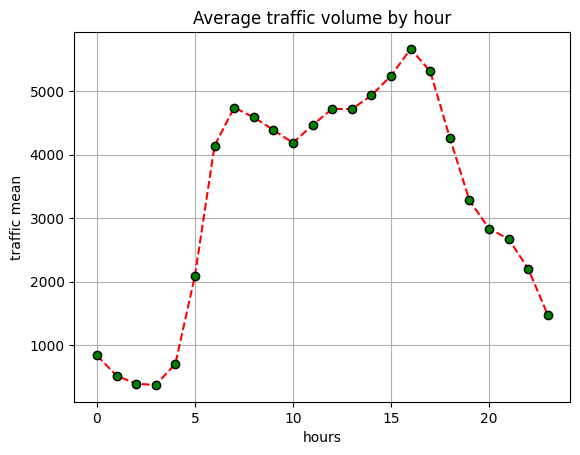

In [63]:
data.groupby('hour')['traffic_volume'].mean().plot(marker='o' , ls = '--' , c = 'red' , mfc = 'green' , mec = 'black')
plt.title('Average traffic volume by hour')
plt.xlabel('hours')
plt.ylabel('traffic mean')
plt.grid(True)
plt.show()

its clearly visible that traffic gets a huge bump from 5 and has a peak at around 16 , then theres a massive drop by 20

# day's of the week wise checking the traffic volume

In [64]:
data['days_of_week'] = data['date_time'].dt.dayofweek

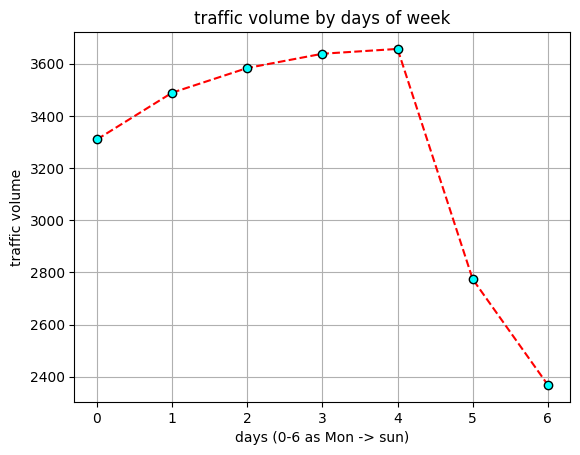

In [66]:
data.groupby('days_of_week')['traffic_volume'].mean().plot(marker = 'o' , mfc = 'cyan' , c = 'red' , mec = 'black' , ls ='--')
plt.title('traffic volume by days of week')
plt.xlabel('days (0-6 as Mon -> sun)')
plt.ylabel('traffic volume')
plt.grid(True)
plt.show()

this proves that week days (monday to friday) experience a good amount of traffic , where as weekends are calm.  
the peak traffic is been experienced at 4th day meaning friday. least traffic at sunday

# traffic changes throughout the year (seasons)

In [68]:
data['month'] = data['date_time'].dt.month

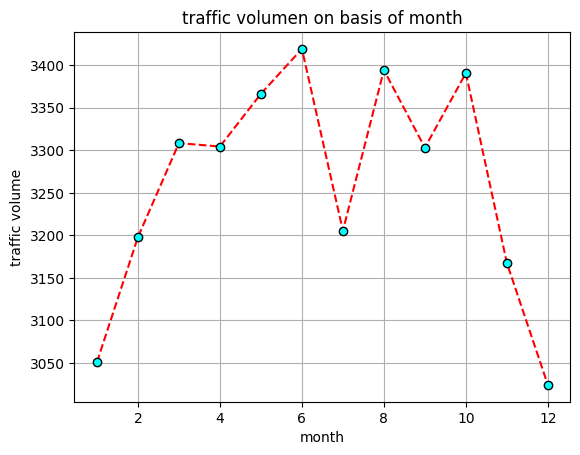

In [72]:
data.groupby('month')['traffic_volume'].mean().plot(marker = 'o' , mfc = 'cyan' , mec = 'black' , ls = '--' , c = 'red')
plt.title('traffic volumen on basis of month')
plt.xlabel('month')
plt.ylabel('traffic volume')
plt.grid(True)
plt.show()

visibly months affect traffic more than that of hours , ofc , though currently day wise affecting is the most important feature

traffic seems lower in january , february , but starts to grou from february to march.  
it is noticed to be at the peak in may ,which is understandable there are summer vacations . we can see a massive drop by july , and then again a cliffing ni sept. the traffic usually comes to an end by the end of december

# lets check how does the weather affect traffic , which is a very understandable importance but lets check it through our data

In [73]:
data['weather_main'].value_counts()

weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [76]:
data.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'is_holiday',
       'hour', 'days_of_week', 'month'],
      dtype='str')

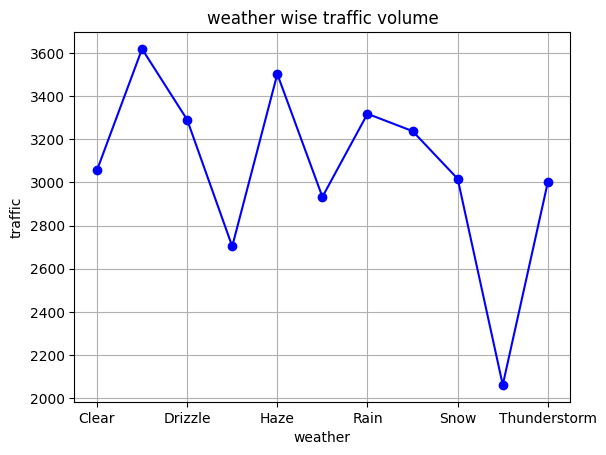

In [79]:
data.groupby('weather_main')['traffic_volume'].mean().plot(marker = 'o' , color = 'blue')
plt.title('weather wise traffic volume')
plt.ylabel('traffic')
plt.xlabel('weather')
plt.grid(True)
plt.show()

In [81]:
data.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)

weather_main
Clouds          3618.449749
Haze            3502.101471
Rain            3317.905501
Drizzle         3290.727073
Smoke           3237.650000
Clear           3055.908819
Snow            3016.844228
Thunderstorm    3001.620890
Mist            2932.956639
Fog             2703.720395
Squall          2061.750000
Name: traffic_volume, dtype: float64

there is something fishy , why is the traffic more during clouds , haze , rain , drizzle , than clear weather ? well maybee cos
clear weather mostly occures at night hours and day hours are all cloudy ? and that can cause traffic to be more in cloudy weather as its in daytime and daytime traffic > nightime traffic .. well this is a correlation !

lets check if traffic volume is correlated with temperature. ill need temperature in degree celcious for better understanding , kelvin is not standard.

In [82]:
data['temperature_celcious'] = data['temp'] - 273.15

In [83]:
data[['temperature_celcious' , 'traffic_volume']].corr()

,temperature_celcious,traffic_volume
temperature_celcious,1.000000,0.130299
traffic_volume,0.130299,1.000000


soo thats a weak positive relation , means with increase in temperature , a very little amount of traffic is increased. soo temperature is not a major predictor or has less importance. its still someone from hours , days , and month. while the **weather** is quite unclear 

lets check correlation with rain ! that can get real!

In [84]:
data[['rain_1h' , 'traffic_volume']].corr()

,rain_1h,traffic_volume
rain_1h,1.000000,0.004714
traffic_volume,0.004714,1.000000


well this is a very weak positive relation. fine , so this is not a major contributer either

let me check the outliers in traffic volume.

In [85]:
data['traffic_volume'].describe()

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

In [90]:
(data['traffic_volume'] == 0).sum()

np.int64(2)

well min is 0 , that is sus

2 rows got zeroes out of 48 thousand , 2 rows wont affect much though , lets still check those out

In [91]:
data[data['traffic_volume'] == 0]

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,is_holiday,hour,days_of_week,month,temperature_celcious
25186,NaN,296.68,0.0,0.0,40,Rain,light rain,2016-07-23 18:00:00,0,0,18,5,7,23.53
25191,NaN,295.90,0.0,0.0,90,Haze,haze,2016-07-23 23:00:00,0,0,23,5,7,22.75


its at saturday 6pm and saturday 11pm , 6pm is sus as that cant be true. thats probably sensor malfunction. well ill prefer to remove these rows

In [92]:
data = data[data['traffic_volume'] > 0]

# lets describe data on basis of weekends , a new powerfull feature

In [ ]:
data['is_weekend'] = data['days_of_week'].isin([5,6]).astype(int)

In [101]:
data['is_weekend'].value_counts()

is_weekend
False    34501
True     13701
Name: count, dtype: int64

In [102]:
weekdays = data[~data['is_weekend']]
weekends = data[data['is_weekend']]


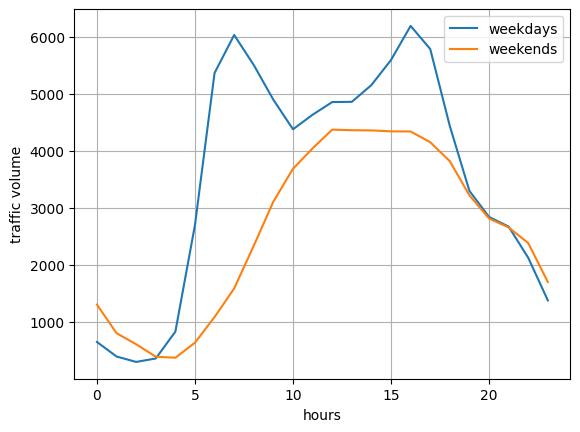

In [104]:
plt.Figure(figsize=(10,8))
weekdays.groupby('hour')['traffic_volume'].mean().plot(label = 'weekdays')
weekends.groupby('hour')['traffic_volume'].mean().plot(label = 'weekends')


plt.xlabel('hours')
plt.ylabel('traffic volume')
plt.legend()
plt.grid(True)
plt.show()

well this makes it clear weekdays experience more trafic !

In [108]:
data['is_rush_hour'] = (
    ((data['hour'] >= 6) & (data['hour'] <= 9)) | ((data['hour'] >= 15) & (data['hour'] <= 18))
).astype(int)

In [109]:
data['weather_main'].value_counts()

weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5671
Snow             2876
Drizzle          1821
Haze             1359
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64